# Fase 3. Preprocesamiento y reducción de dimensión

Se prepara Saber 11 2020-2 para un modelo futuro. No se entrena ningún modelo.

Decisiones, alineadas con el EDA:

- Las categóricas vacías quedan como "No responde". Borrar filas por el cuestionario botaría cerca del 3 % y, en bilingüe, mucho más.
- Se eliminan solo las filas sin puntaje de inglés (una fracción pequeña). Ese puntaje entra al PCA.
- No se usa el puntaje global: es casi la suma de las cinco áreas.
- Estrato, educación, género, colegio, internet, computador y horas de trabajo se codifican con variables indicadoras.
- Todo el bloque se estandariza. Si solo se escalan los puntajes, las indicadoras (0/1) no compiten con desviaciones de 10 puntos y el PCA se vuelve una copia de las notas.
- El escalador se ajusta sobre toda la tabla porque esta fase todavía no parte entrenamiento y prueba. En un modelo sí habría que ajustarlo solo con entrenamiento.
- Los puntajes extremos se quedan. El EDA ya justificó por qué.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name in {"01_exploracion", "02_eda", "03_preprocesamiento"}:
    ROOT = ROOT.parent

RAW = ROOT / "data" / "raw"
AUDIO = ROOT / "data" / "audio"
FIG = ROOT / "resultados" / "figuras"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

PUNTAJES = [
    "PUNT_LECTURA_CRITICA",
    "PUNT_MATEMATICAS",
    "PUNT_C_NATURALES",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_INGLES",
]
CATEGORICAS = [
    "ESTU_GENERO",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_EDUCACIONMADRE",
    "COLE_NATURALEZA",
    "COLE_AREA_UBICACION",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENECOMPUTADOR",
    "ESTU_HORASSEMANATRABAJA",
]
df = pd.read_csv(RAW / "saber11_2020_2.csv", usecols=PUNTAJES + CATEGORICAS, low_memory=False)
print("Filas leídas:", len(df))
antes = len(df)
df = df.dropna(subset=["PUNT_INGLES"]).copy()
print(f"Filas sin puntaje de inglés eliminadas: {antes - len(df)}")
for col in CATEGORICAS:
    df[col] = df[col].fillna("No responde")
df[CATEGORICAS].nunique()


Filas leídas: 504872
Filas sin puntaje de inglés eliminadas: 334


ESTU_GENERO                 3
FAMI_ESTRATOVIVIENDA        8
FAMI_EDUCACIONMADRE        13
COLE_NATURALEZA             2
COLE_AREA_UBICACION         2
FAMI_TIENEINTERNET          3
FAMI_TIENECOMPUTADOR        3
ESTU_HORASSEMANATRABAJA     6
dtype: int64

In [2]:
indicadoras = pd.get_dummies(df[CATEGORICAS], drop_first=True, dtype=float)
matriz = pd.concat([df[PUNTAJES].reset_index(drop=True), indicadoras.reset_index(drop=True)], axis=1)
print("Dimensiones antes de PCA:", matriz.shape)

escalador = StandardScaler()
z = escalador.fit_transform(matriz)

pca = PCA(random_state=42)
componentes = pca.fit_transform(z)
var = pca.explained_variance_ratio_
acum = np.cumsum(var)
print("Varianza explicada por las primeras 10 componentes:")
print(pd.Series(var[:10], index=[f"PC{i}" for i in range(1, 11)]).round(3).to_string())
print(f"Componentes para acumular al menos 80 %: {int(np.searchsorted(acum, 0.80) + 1)}")
print(f"PC1 + PC2: {acum[1] * 100:.1f}%")


Dimensiones antes de PCA: (504538, 37)


Varianza explicada por las primeras 10 componentes:
PC1    0.131
PC2    0.109
PC3    0.043
PC4    0.040
PC5    0.034
PC6    0.033
PC7    0.032
PC8    0.031
PC9    0.030
PC10   0.030
Componentes para acumular al menos 80 %: 21
PC1 + PC2: 23.9%


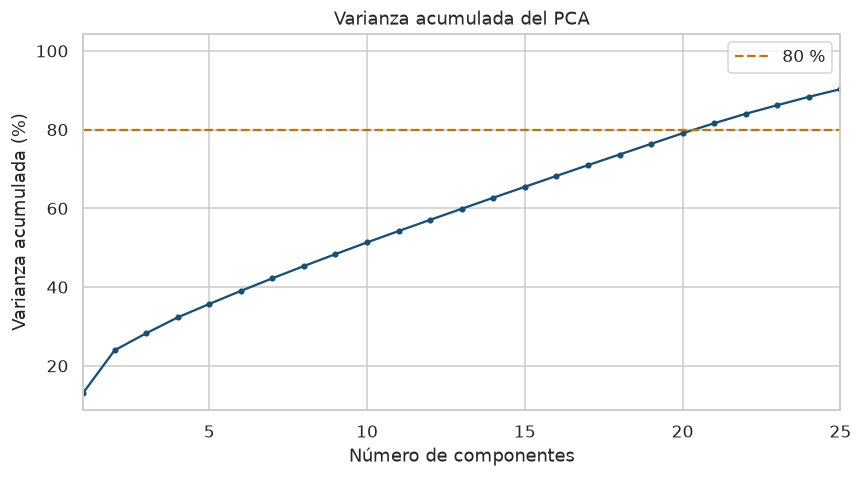

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(acum) + 1), acum * 100, marker="o", ms=3, color="#1b4f72")
ax.axhline(80, color="#b9770e", linestyle="--", label="80 %")
ax.set_xlabel("Número de componentes")
ax.set_ylabel("Varianza acumulada (%)")
ax.set_title("Varianza acumulada del PCA")
ax.set_xlim(1, min(25, len(acum)))
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "03_varianza_pca.png", bbox_inches="tight")
plt.show()


In [4]:
cargas = pd.DataFrame(pca.components_[:2].T, index=matriz.columns, columns=["PC1", "PC2"])
top_pc1 = cargas["PC1"].abs().sort_values(ascending=False).head(8).index
top_pc2 = cargas["PC2"].abs().sort_values(ascending=False).head(8).index
print("Mayores cargas en PC1")
print(cargas.loc[top_pc1, "PC1"].round(3).to_string())
print("\nMayores cargas en PC2")
print(cargas.loc[top_pc2, "PC2"].round(3).to_string())

puntajes_pc1 = cargas.loc[PUNTAJES, "PC1"]
mismo_signo = puntajes_pc1.gt(0).all() or puntajes_pc1.lt(0).all()
print("\nLos cinco puntajes tienen el mismo signo en PC1:" , bool(mismo_signo))


Mayores cargas en PC1
PUNT_C_NATURALES                  0.320
PUNT_SOCIALES_CIUDADANAS          0.313
PUNT_LECTURA_CRITICA              0.308
PUNT_INGLES                       0.307
PUNT_MATEMATICAS                  0.305
FAMI_TIENEINTERNET_Si             0.258
FAMI_TIENECOMPUTADOR_Si           0.253
FAMI_TIENEINTERNET_No responde   -0.243

Mayores cargas en PC2
FAMI_EDUCACIONMADRE_No responde       0.381
FAMI_TIENEINTERNET_No responde        0.380
ESTU_HORASSEMANATRABAJA_No responde   0.367
FAMI_ESTRATOVIVIENDA_No responde      0.356
FAMI_TIENECOMPUTADOR_No responde      0.345
PUNT_SOCIALES_CIUDADANAS              0.239
PUNT_LECTURA_CRITICA                  0.234
PUNT_MATEMATICAS                      0.225

Los cinco puntajes tienen el mismo signo en PC1: True


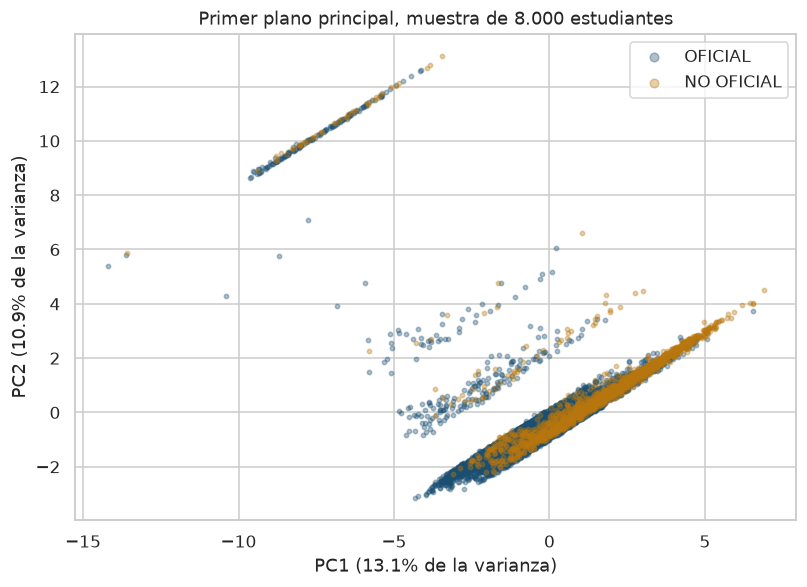

In [5]:
plano = pd.DataFrame(componentes[:, :2], columns=["PC1", "PC2"])
plano["naturaleza"] = df["COLE_NATURALEZA"].to_numpy()
muestra = plano.sample(8000, random_state=42)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for naturaleza, color in [("OFICIAL", "#1b4f72"), ("NO OFICIAL", "#b9770e")]:
    parte = muestra[muestra["naturaleza"] == naturaleza]
    ax.scatter(parte["PC1"], parte["PC2"], s=8, alpha=0.35, c=color, label=naturaleza)
ax.set_xlabel(f"PC1 ({var[0] * 100:.1f}% de la varianza)")
ax.set_ylabel(f"PC2 ({var[1] * 100:.1f}% de la varianza)")
ax.set_title("Primer plano principal, muestra de 8.000 estudiantes")
ax.legend(markerscale=2)
fig.tight_layout()
fig.savefig(FIG / "03_plano_pca.png", bbox_inches="tight")
plt.show()


In [6]:
texto_eje = (
    "PC1 junta los cinco puntajes con el mismo signo: es un eje de desempeño. "
    "Quien saca más alto en las áreas queda hacia un costado de ese eje."
    if mismo_signo
    else "PC1 no agrupa los cinco puntajes con el mismo signo; las cargas hay que leerlas variable por variable."
)
nombres_pc2 = [str(nombre) for nombre in top_pc2[:5]]
if sum("No responde" in nombre for nombre in nombres_pc2) >= 3:
    texto_pc2 = (
        "Las cargas más grandes de PC2 son "
        + ", ".join(nombres_pc2)
        + ". Ese eje agrupa a quien dejó el cuestionario en blanco: las indicadoras de no respuesta viajan juntas. No mide el desempeño ni ordena el estrato."
    )
else:
    texto_pc2 = "Las cargas más grandes de PC2 son " + ", ".join(nombres_pc2) + "."
resumen = f"""# Preprocesamiento

- Filas usadas: {len(df):,} (se quitaron solo los registros sin puntaje de inglés).
- Matriz para PCA: {matriz.shape[1]} columnas ({len(PUNTAJES)} puntajes y el resto indicadoras).
- PC1 explica el {var[0] * 100:.1f}% y PC2 el {var[1] * 100:.1f}%. Juntas, {acum[1] * 100:.1f}%.
- Hacen falta {int(np.searchsorted(acum, 0.80) + 1)} componentes para pasar el 80 % de la varianza. Dos componentes no alcanzan para reemplazar la tabla: el contexto socioeconómico queda repartido en ejes siguientes.
- {texto_eje}
- {texto_pc2}
"""
destino = ROOT / "03_preprocesamiento" / "pca.md"
destino.write_text(resumen, encoding="utf-8")
print(resumen)


# Preprocesamiento

- Filas usadas: 504,538 (se quitaron solo los registros sin puntaje de inglés).
- Matriz para PCA: 37 columnas (5 puntajes y el resto indicadoras).
- PC1 explica el 13.1% y PC2 el 10.9%. Juntas, 23.9%.
- Hacen falta 21 componentes para pasar el 80 % de la varianza. Dos componentes no alcanzan para reemplazar la tabla: el contexto socioeconómico queda repartido en ejes siguientes.
- PC1 junta los cinco puntajes con el mismo signo: es un eje de desempeño. Quien saca más alto en las áreas queda hacia un costado de ese eje.
- Las cargas más grandes de PC2 son FAMI_EDUCACIONMADRE_No responde, FAMI_TIENEINTERNET_No responde, ESTU_HORASSEMANATRABAJA_No responde, FAMI_ESTRATOVIVIENDA_No responde, FAMI_TIENECOMPUTADOR_No responde. Ese eje agrupa a quien dejó el cuestionario en blanco: las indicadoras de no respuesta viajan juntas. No mide el desempeño ni ordena el estrato.

